In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from math import sqrt


data = pd.read_csv('/kaggle/input/newdata/ProductionDataAll - Copy.csv')

In [2]:
# Convert the 'Date' column to datetime
data['Date'] = pd.to_datetime(data['Date'])

In [3]:
# Interpolate missing values
data['Temperature'] = data['Temperature'].interpolate()

In [4]:
# Get unique country names
countries = data['Country'].unique()

In [5]:
# Prepare the temperature data as a time series indexed by date
for country in countries:
    country_data = data[data['Country'] == country]
    country_data.set_index('Date', inplace=True)

In [6]:
#Fit an ETS model for each country with trend and seasonal components.
ets_models = {}
for country in countries:
    country_data = data[data['Country'] == country]
    model = ExponentialSmoothing(
        country_data['Temperature'],
        seasonal='add',  # or 'mul' if the seasonality is multiplicative
        trend='add',     # or 'mul' if the trend is multiplicative
        seasonal_periods=12  # The number of seasonal periods in a year
    ).fit()
    ets_models[country] = model


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot

In [7]:
# Evaluate the performance of the ETS models
for country, model in ets_models.items():
    country_data = data[data['Country'] == country]
    fitted_values = model.fittedvalues
    mae = mean_absolute_error(country_data['Temperature'], fitted_values)
    mse = mean_squared_error(country_data['Temperature'], fitted_values)
    rmse = sqrt(mse)
    mape = mean_absolute_percentage_error(country_data['Temperature'], fitted_values)
    print(f'{country} - MAE: {mae}, RMSE: {rmse}, MAPE: {mape}',)


Argentina - MAE: 0.7031445738036451, RMSE: 0.9034932782513957, MAPE: 0.056833210928755595
Bolivia - MAE: 0.6526107660670045, RMSE: 0.9550722996435812, MAPE: 0.03154551990796931
Brazil - MAE: 0.34884735472980627, RMSE: 0.4296547789800886, MAPE: 0.013678061648865423
Chile - MAE: 0.47734229921198357, RMSE: 0.7266446835801641, MAPE: 0.055950203851822006
Colombia - MAE: 0.31314354110759596, RMSE: 0.43124461276282844, MAPE: 0.012366082250354429
Ecuador - MAE: 0.2832840089057469, RMSE: 0.3713802870079676, MAPE: 0.012878816530864343
Guyana - MAE: 0.33444125198713753, RMSE: 0.4300465977860759, MAPE: 0.012593025141311913
Paraguay - MAE: 0.9962329501785455, RMSE: 1.328951501853997, MAPE: 0.044461742252190316
Peru - MAE: 0.3366253170849025, RMSE: 0.43137367143780825, MAPE: 0.016201442236676564
Suriname - MAE: 0.3213819229725117, RMSE: 0.41674768024020015, MAPE: 0.011908033780138737
Uruguay - MAE: 0.9598365548265186, RMSE: 1.2119691388452751, MAPE: 0.05964299581961516
Venezuela - MAE: 0.32232878477

In [8]:
# calculate overall MAE, RMSE, and MAPE
overall_mae = np.mean([mean_absolute_error(data[data['Country'] == country]['Temperature'], ets_models[country].fittedvalues) for country in countries])
overall_rmse = np.mean([sqrt(mean_squared_error(data[data['Country'] == country]['Temperature'], ets_models[country].fittedvalues)) for country in countries])
overall_mape = np.mean([mean_absolute_percentage_error(data[data['Country'] == country]['Temperature'], ets_models[country].fittedvalues) for country in countries])
print(f'Overall - MAE: {overall_mae}, RMSE: {overall_rmse}, MAPE: {overall_mape}')

Overall - MAE: 0.5041016104706308, RMSE: 0.6701343399531035, MAPE: 0.02837636905362638


In [9]:
forecasts = {}
for country, model in ets_models.items():
    forecast = model.forecast(steps=60)
    forecasts[country] = forecast

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/u

In [10]:
# Create a DataFrame to store the forecasts
future_dates = pd.date_range(start='2025-01-01', periods=60, freq='M')
for country, forecast in forecasts.items():
    forecast_df = pd.DataFrame({
        'Date': future_dates,
        'Forecast': forecast
    })

In [11]:
forecast_data = []
for country, forecast in forecasts.items():
    # Reset the index of the forecast Series to a simple integer range
    forecast = forecast.reset_index(drop=True)
    for i in range(len(forecast)):
        forecast_data.append([country, future_dates[i], forecast[i]])

forecast_df = pd.DataFrame(forecast_data, columns=['Country', 'Date', 'Temperature'])
#forecast_df['Date] to first day of the month
forecast_df['Date'] = forecast_df['Date'].dt.to_period('M').dt.to_timestamp()

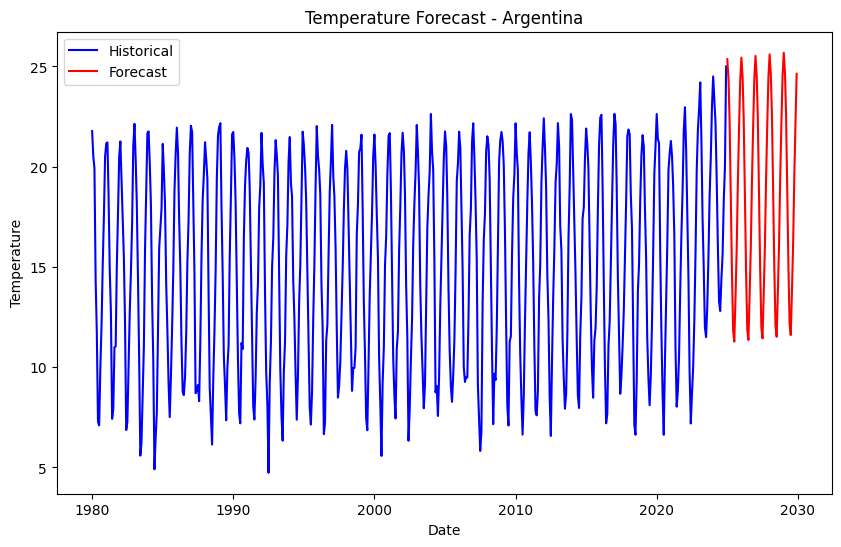

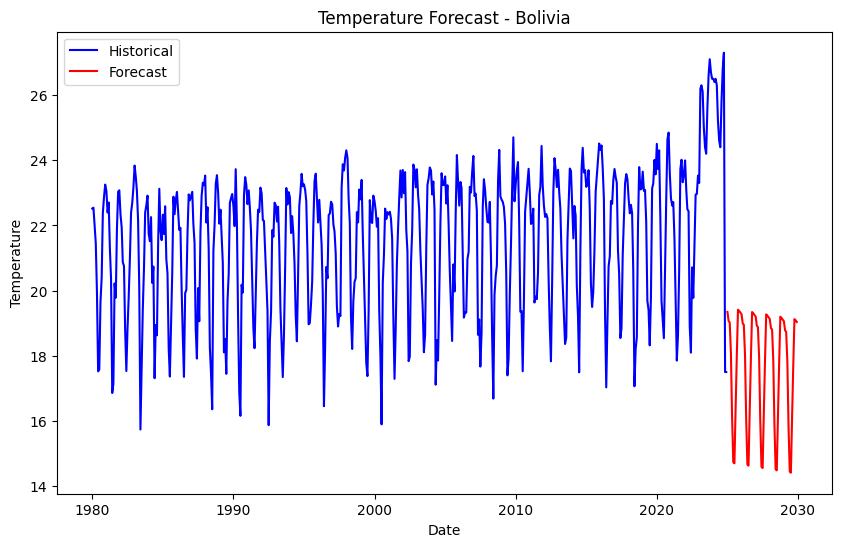

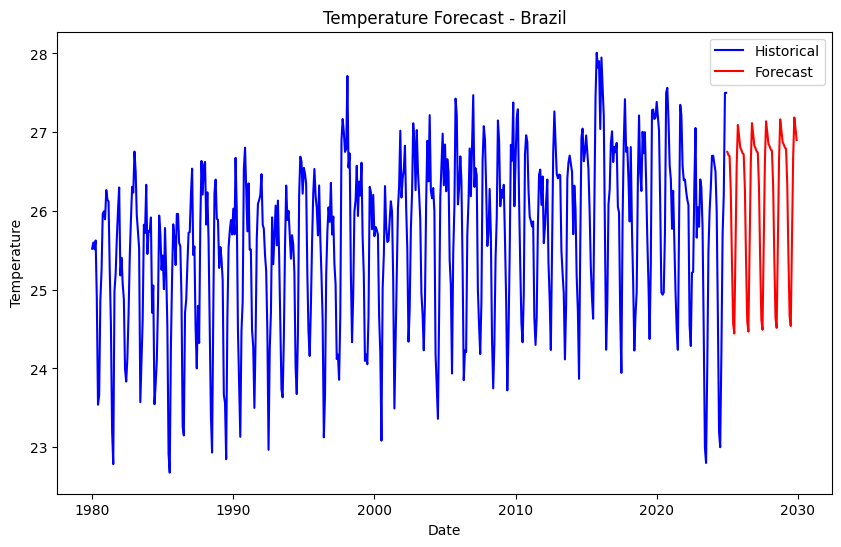

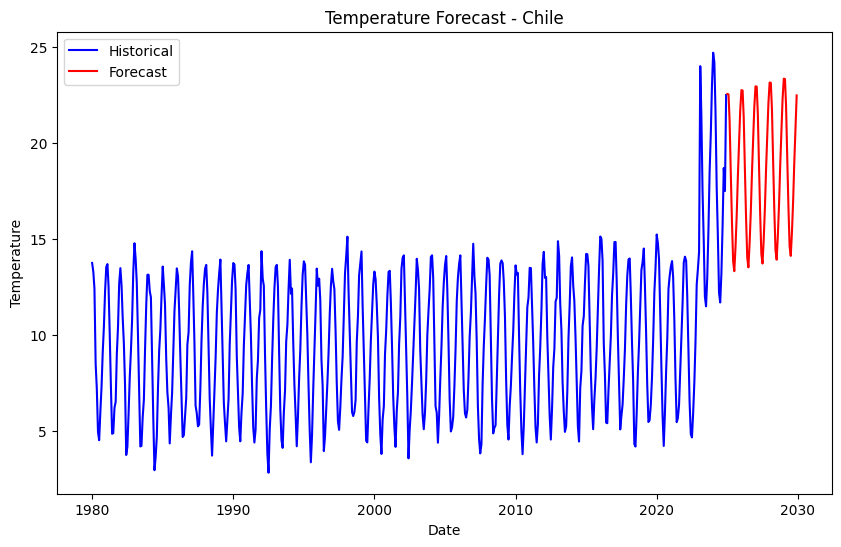

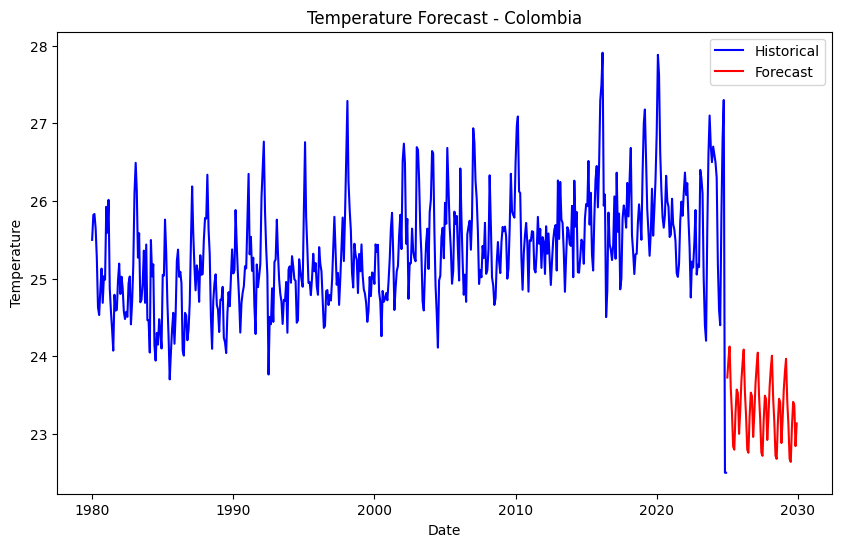

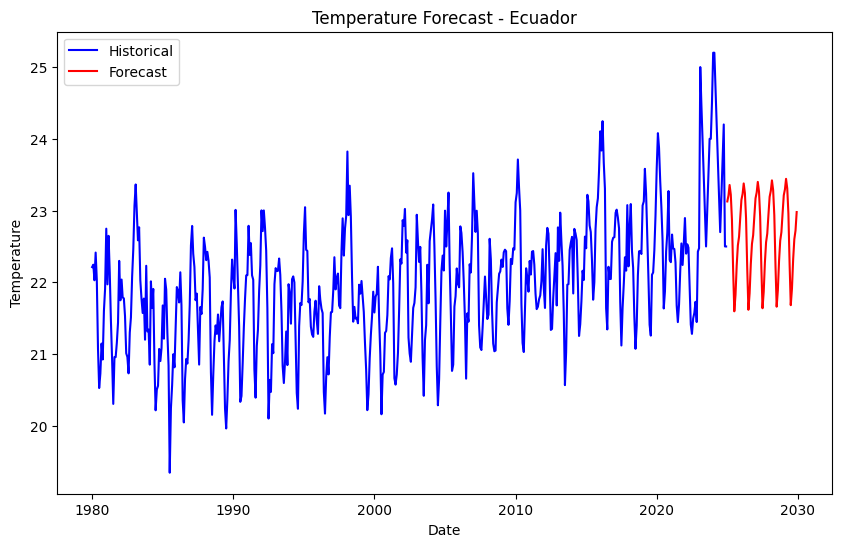

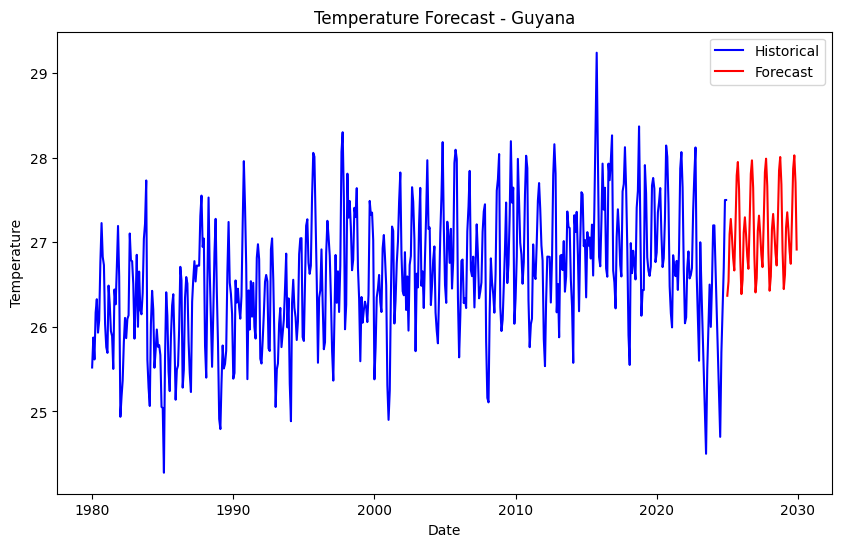

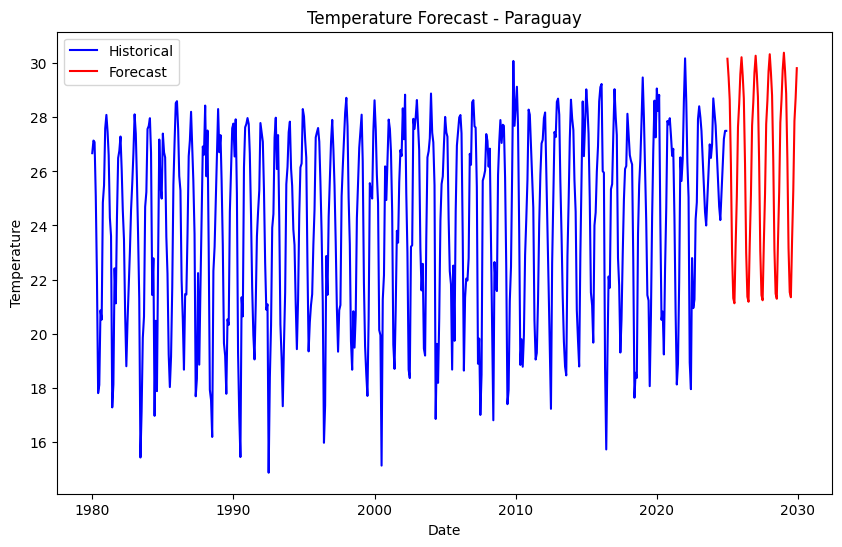

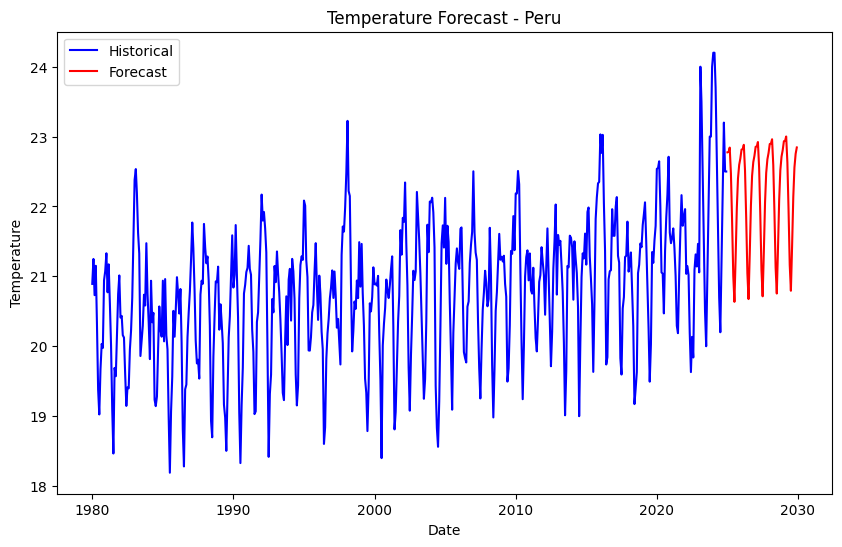

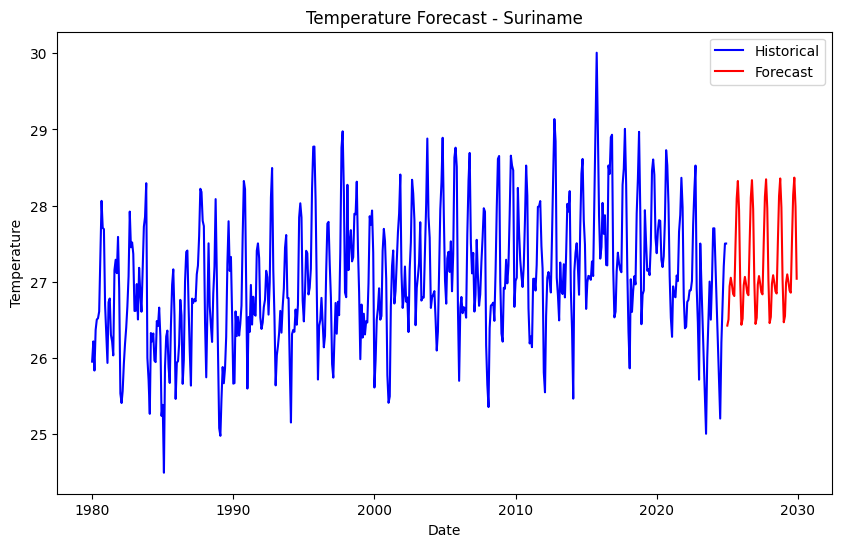

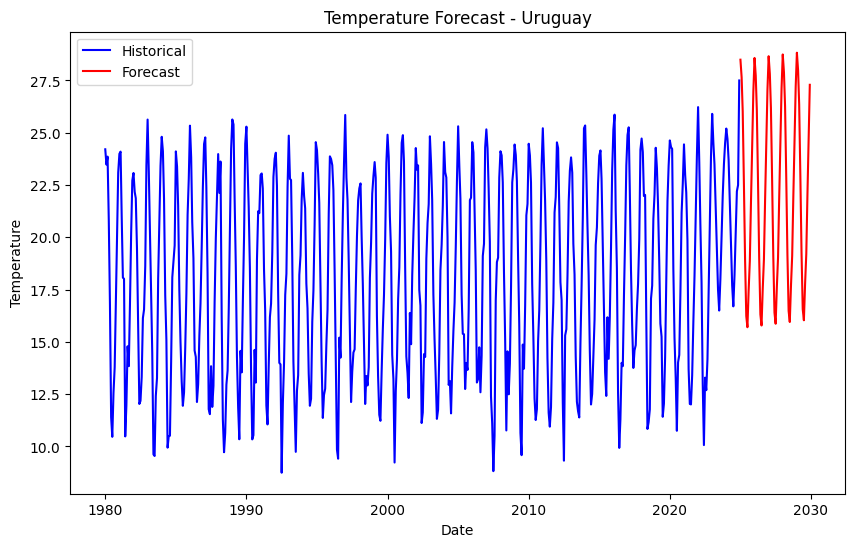

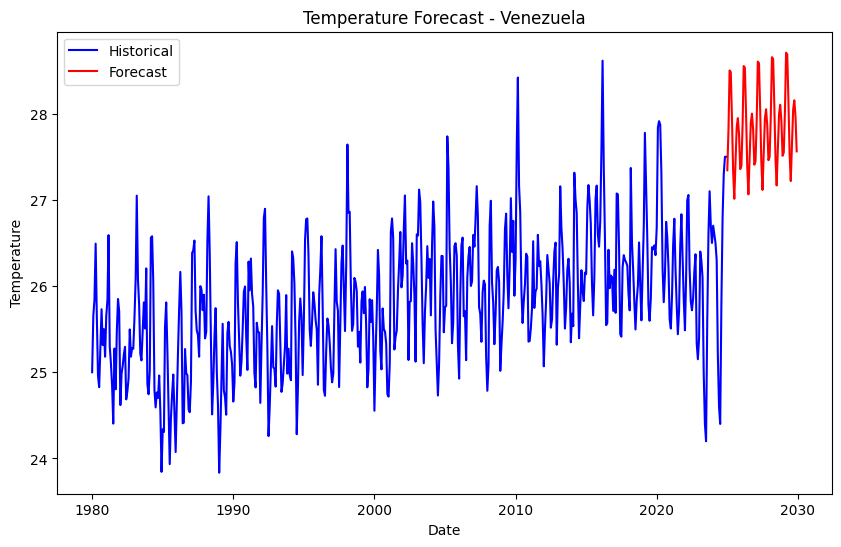

In [12]:
from matplotlib import pyplot as plt
for country in countries:
    country_data = data[data['Country'] == country]
    forecast_data = forecast_df[forecast_df['Country'] == country]
    plt.figure(figsize=(10, 6))
    plt.plot(country_data['Date'], country_data['Temperature'], label='Historical', color= 'b')
    plt.plot(forecast_data['Date'], forecast_data['Temperature'], label='Forecast', color = 'r')
    plt.title(f'Temperature Forecast - {country}')
    plt.xlabel('Date')
    plt.ylabel('Temperature')
    plt.legend()
    plt.show()

In [13]:
forecast_df.to_csv('Exponential Smoothing Data.csv')